In [1]:
import sys
print(sys.executable)

c:\Users\deniz\OneDrive\Masaüstü\2024_YR4\yr4_venv\Scripts\python.exe


In [2]:
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


<span style="font-size:24px"> ASTEROID 2024 YR4 Characterization, Beta Estimation, Escape Velocity Calculation</span> <br>

In [3]:
import webbrowser
webbrowser.open("https://cneos.jpl.nasa.gov/sentry/details.html#?des=2024%20YR4")

print("\033[31mAsteroid diameter is in between 50 m - 70 m. The mass of asteoid is 210,000 tons on Sentry: Earth Impact Monitoring.\033[0m")
print("\033[31mSince most likely type is S-type for most Apollo type asteroid, 2024 YR4 density must be in S-type asteroid density range.\n\033[0m")
print("For more information for 2024 YR4: https://en.wikipedia.org/wiki/2024_YR4 ")

print("Based on this consideration, I tried to \033[31mget density values for 100 diameter values in 50 - 70 m.\033[0m")
print("Then by using S-type asteroid density limits \033[31m(1.9 g/cm³ and 3.7 g/cm³)\033[0m and mass information of asteroid, diameters are calculated when mass still is 210,000 tons")

Asteroid diameter is in between 50 m - 70 m. The mass of asteoid is 210,000 tons on Sentry: Earth Impact Monitoring.
Since most likely type is S-type for most Apollo type asteroid, 2024 YR4 density must be in S-type asteroid density range.

For more information for 2024 YR4: https://en.wikipedia.org/wiki/2024_YR4 
Based on this consideration, I tried to get density values for 100 diameter values in 50 - 70 m.
Then by using S-type asteroid density limits (1.9 g/cm³ and 3.7 g/cm³) and mass information of asteroid, diameters are calculated when mass still is 210,000 tons


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Constant
mass = 2.1e8  # kg
diameter_min = 50  # m
diameter_max = 70  # m

# S-type density interval (min value and max value) (g/cm³)
s_type_min = 1.9 # g/cm³
s_type_max = 3.7 # g/cm³
assumed_density = 2.6 # g/cm³ which is within the density range for stony asteroids such as 243 Ida

# Calculate Exact Density with diameter value ( In range between 50-70 m)
def calculate_density(mass, diameter):
    """
    Calculates density by using mass and diameter to check if its in limits
    """
    radius = diameter / 2
    volume = (4/3) * math.pi * radius**3  # m³
    density_kg_m3 = mass / volume
    density_g_cm3 = density_kg_m3 / 1000  # kg/m³ to g/cm³
    return density_g_cm3

# Density calculation from min diameter to max diameter ( 100 numbers in between these values) 
diameters = np.linspace(diameter_min, diameter_max, 100) 
densities = [calculate_density(mass, d) for d in diameters]

# Minimum ve maximum density values
min_density = min(densities)
max_density = max(densities)

print(f"Diameter range: {diameter_min} - {diameter_max} m")
print(f"Calculated density range: {min_density:.3f} - {max_density:.3f} g/cm³")
print(f"S-type density interval: {s_type_min} - {s_type_max} g/cm³")

# Calculate Exact Diameter with density value ( In range between s_type_min = 1.9- 3.7 g/cm³)
def calculate_diameter_from_density(mass, density_g_cm3):
    """This calculates exact diameter for its matching density values"""
    density_kg_m3 = density_g_cm3 * 1000
    volume = mass / density_kg_m3
    radius = ((3 * volume) / (4 * math.pi)) ** (1/3)
    diameter = 2 * radius
    return diameter

# Point A : Finding Density @50 m asteroid diameter by using first function calculate_density
diameter_a = 50
density_a = calculate_density(mass, diameter_a)

# Point B : Finding Diameter @ρ = 1.9 g/cm³ by using second function calculate_diameter_from_density
density_b = 1.9
diameter_b = calculate_diameter_from_density(mass, density_b)

# Point C : Finding Diameter @ρ = 2.6 g/cm³ by using second function calculate_diameter_from_density
density_c = assumed_density
diameter_c = calculate_diameter_from_density(mass, density_c)

# Point D : Finding Density @58.42  m asteroid diameter by using first function calculate_density
diameter_d = 58.42# m 
#"For more information for 2024 YR4: https://science.nasa.gov/solar-system/asteroids/2024-yr4-facts/
density_d = calculate_density(mass, diameter_d)

print(f"A point - Diameter: {diameter_a} m, Density: {density_a:.4f} g/cm³")
print(f"B point - Density: {density_b} g/cm³, Diameter: {diameter_b:.4f} m") # Min density value for S-type Asteroid
print(f"C point - Density: {density_c} g/cm³, Diameter: {diameter_c:.4f} m") # Min density value for S-type Asteroid
print(f"D point -  Diameter: {diameter_d} g/cm³, Density: {density_d:.4f} m") # Min density value for S-type Asteroid

Diameter range: 50 - 70 m
Calculated density range: 1.169 - 3.209 g/cm³
S-type density interval: 1.9 - 3.7 g/cm³
A point - Diameter: 50 m, Density: 3.2086 g/cm³
B point - Density: 1.9 g/cm³, Diameter: 59.5419 m
C point - Density: 2.6 g/cm³, Diameter: 53.6310 m
D point -  Diameter: 58.42 g/cm³, Density: 2.0116 m


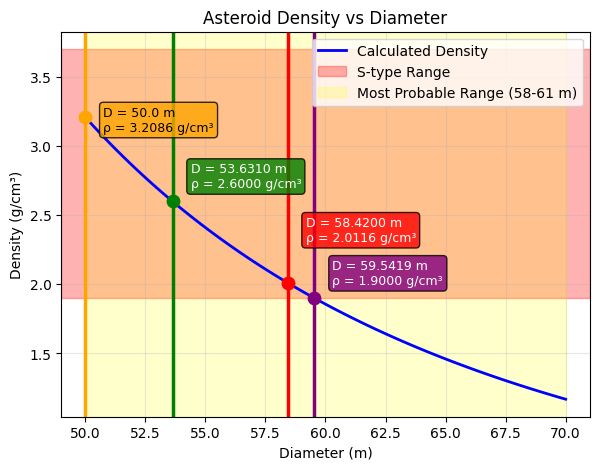

In [7]:
# Plot 1: Density vs Diameter
plt.figure(figsize=(15, 5)) #Figure Size: 15 → Width, 5 → Height

plt.subplot(1, 2, 1)
plt.plot(diameters, densities, 'b-', linewidth=2, label='Calculated Density')
plt.axhspan(s_type_min, s_type_max, alpha=0.3, color='red', label='S-type Range')

# Highlight most probable diameter range (58-61 m)
plt.axvspan(diameter_min, diameter_max, color='yellow', 
            alpha=0.2, label='Most Probable Range (58-61 m)')

# A - B - C - D lines on plot
plt.axvline(x=diameter_a, color='orange', linestyle='-', linewidth=2.5)
plt.axvline(x=diameter_b, color='purple', linestyle='-', linewidth=2.5)
plt.axvline(x=diameter_c, color='green', linestyle='-', linewidth=2.5)
plt.axvline(x=diameter_d, color='red', linestyle='-', linewidth=2.5)

# A - B - C - D dots on plot
plt.scatter([diameter_a], [density_a], color='orange', s=80, zorder=5)
plt.scatter([diameter_b], [density_b], color='purple', s=80, zorder=5)
plt.scatter([diameter_c], [density_c], color='green', s=80, zorder=5)
plt.scatter([diameter_d], [density_d], color='red', s=80, zorder=5)

# A - B - C - D values on box
plt.text(diameter_a + 0.75, density_a - 0.1, f'D = {diameter_a:.1f} m\nρ = {density_a:.4f} g/cm³', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='orange', alpha=0.8), 
         fontsize=9, ha='left')
plt.text(diameter_b + 0.75 , density_b + 0.1, f'D = {diameter_b:.4f} m\nρ = {density_b:.4f} g/cm³', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='purple', alpha=0.8), 
         fontsize=9, ha='left', color='white')
plt.text(diameter_c + 0.75 , density_c + 0.1, f'D = {diameter_c:.4f} m\nρ = {density_c:.4f} g/cm³', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='green', alpha=0.8), 
         fontsize=9, ha='left', color='white')
plt.text(diameter_d + 0.75 , density_d + 0.3, f'D = {diameter_d:.4f} m\nρ = {density_d:.4f} g/cm³', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.8), 
         fontsize=9, ha='left', color='white')

plt.xlabel('Diameter (m)')
plt.ylabel('Density (g/cm³)')
plt.title('Asteroid Density vs Diameter')
plt.grid(True, alpha=0.3)
plt.legend()

Mass Values (tons): [265617.0511917917, 268374.2997246253, 271150.56368947244, 273945.9084314605, 276760.39929571655, 294053.07237600465, 297003.41575969843]
The mass values (most likely): 271429.2384505053


Text(58.620000000000005, 271426.2384505053, 'D = 58.42 m\nρ = 271429.2385 tons')

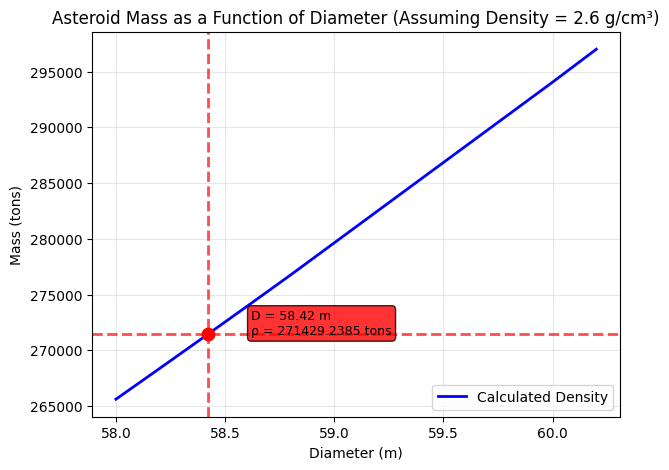

In [8]:
assumed_density = 2.6   # g/cm³
possible_diameter = 58.42 # m

def calculate_mass(density_kgm3, possible_diameters):
    """
    Calculates mass for a list of diameters based on given density.
    Returns a list of mass values in kg.
    """
    masses = []
    for diameter in possible_diameters:
        radius = diameter / 2
        volume = (4/3) * math.pi * (radius ** 3)  # m³
        mass = density_kgm3 * volume              # kg
        masses.append(mass)
    return masses

# Yoğunluğu kg/m³ cinsine çeviriyoruz
assumed_density_kgm3 = assumed_density * 1000  # 2.6 g/cm³ → 2600 kg/m³

possible_diameters = [58, 58.2, 58.4, 58.6, 58.8, 60, 60.2]  # metre cinsinden çaplar
masses = calculate_mass(assumed_density_kgm3, possible_diameters)


# kg → ton dönüşümü (1 ton = 1000 kg)
masses_ton = [m / 1000 for m in masses]

print("Mass Values (tons):", masses_ton)
possible_mass = calculate_mass(assumed_density_kgm3, [possible_diameter])[0]  # kg
possible_mass_ton = possible_mass / 1000  # tona çevir
print(f"The mass values (most likely):", possible_mass_ton)

# Plot 3: Mass Calculation
plt.figure(figsize=(15, 5)) #Figure Size: 15 → Width, 5 → Height

plt.subplot(1, 2, 1)
plt.plot(possible_diameters, masses_ton, 'b-', linewidth=2, label='Calculated Density')
plt.xlabel('Diameter (m)')
plt.ylabel('Mass (tons)')
plt.title('Asteroid Mass as a Function of Diameter (Assuming Density = 2.6 g/cm³)')
plt.axvline(x=possible_diameter, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.axhline(y=possible_mass_ton, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.grid(True, alpha=0.3)
plt.legend()

# Possible Mass Value Dot on plot
plt.scatter(possible_diameter, possible_mass_ton, color='red', s=80, zorder=5)

#  Possible Mass Value Dot on box
plt.text(possible_diameter + 0.2, possible_mass_ton - 3, f'D = {possible_diameter:.2f} m\nρ = {possible_mass_ton:.4f} tons', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.8), 
         fontsize=9, ha='left')

For a density of 2.6 g/cm³, the beta value (β) is calculated as 3.881.

Analysis Results:
A point (50m diameter): 3.209 g/cm³
B point (1.9 g/cm³): 59.5 m diameter
Diameter range: 50 - 70 m
Calculated density range: 1.169 - 3.209 g/cm³

Beta Analysis:
Min density (1.9 g/cm³) → β = 2.828
Max density (3.209 g/cm³) → β = 4.796
Wiki density (2.6 g/cm³) → β = 3.881
Required density for β = 3.6 (DART): 2.413 g/cm³
S-type density range: 1.9 - 3.7 g/cm³

✅ Calculated densities overlap with S-type range!


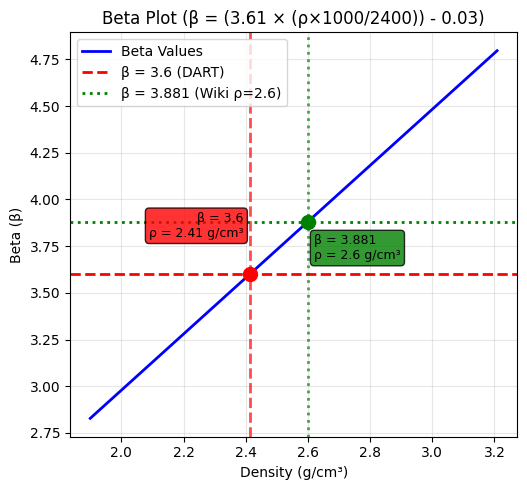

In [9]:
# Plot 2: Beta Plot
plt.figure(figsize=(10, 5)) #Figure Size: 10 → Width, 5 → Height
plt.subplot(1, 2, 1)

# Function for Beta: β = (3.61 × (ρ* 1000/2400)) - 0.03
def calculate_beta(density_g_cm3):
    return (3.61 * (density_g_cm3 * 1000 / 2400)) - 0.03

# Min density = 1.9 g/cm³, Max density = 50m diameter density
min_density_beta = 1.9  # g/cm³
max_density_beta = density_a  # 50m diameter density since its has highest

# Density interval for Beta values 
beta_densities = np.linspace(min_density_beta, max_density_beta, 100)
beta_values = [calculate_beta(rho) for rho in beta_densities]

# Find the density value for Beta = 3.6 since its DART Mission
# 3.6 = (3.61 × (ρ* 1000/2400)) - 0.03
# ρ = ((3.6 + 0.03) * 2400) / (3.61 * 1000)
density_at_beta_DART = ((3.6 + 0.03) * 2400) / (3.61 * 1000)

# Find the Beta value when ρ = 2.6 (Wikipedia density value for 2024 YR4)
wiki_density = 2.6  # g/cm³
beta_wiki = calculate_beta(wiki_density)
print(f"For a density of {wiki_density} g/cm³, the beta value (β) is calculated as {beta_wiki:.3f}.")

# Plot the main beta curve
plt.plot(beta_densities, beta_values, 'b-', linewidth=2, label='Beta Values')

# Beta = 3.6 line (DART Mission)
plt.axhline(y=3.6, color='red', linestyle='--', linewidth=2, label='β = 3.6 (DART)')

# Add vertical line and point for DART density (β = 3.6)
if min_density_beta <= density_at_beta_DART <= max_density_beta:
    plt.axvline(x=density_at_beta_DART, color='red', linestyle='--', linewidth=2, alpha=0.7)
    plt.scatter([density_at_beta_DART], [3.6], color='red', s=100, zorder=5)
    plt.text(density_at_beta_DART - 0.02, 3.8, f'β = 3.6\nρ = {density_at_beta_DART:.2f} g/cm³', 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.8), fontsize=9, ha='right')

# Add visualization for density = 2.6 g/cm³ (Wikipedia value)
if min_density_beta <= wiki_density <= max_density_beta:
    # Horizontal line for beta value at density = 2.6
    plt.axhline(y=beta_wiki, color='green', linestyle=':', linewidth=2, label=f'β = {beta_wiki:.3f} (Wiki ρ=2.6)')
    # Vertical line at density = 2.6
    plt.axvline(x=wiki_density, color='green', linestyle=':', linewidth=2, alpha=0.7)
    # Point at intersection
    plt.scatter([wiki_density], [beta_wiki], color='green', s=100, zorder=5)
    # Text annotation
    plt.text(wiki_density + 0.02, beta_wiki - 0.2, f'β = {beta_wiki:.3f}\nρ = {wiki_density} g/cm³', 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='green', alpha=0.8), fontsize=9, ha='left')

# Add assumed_density line if it exists in your code
# Uncomment the following lines if assumed_density is defined
# plt.axvline(x=assumed_density, color='orange', linestyle='--', linewidth=2, alpha=0.7)
# plt.scatter([assumed_density], [calculate_beta(assumed_density)], color='orange', s=100, zorder=5)
# plt.text(assumed_density - 0.02, calculate_beta(assumed_density) + 0.2, 
#          f'β = {calculate_beta(assumed_density):.3f}\nρ = {assumed_density:.2f} g/cm³', 
#          bbox=dict(boxstyle='round,pad=0.3', facecolor='orange', alpha=0.8), fontsize=9, ha='right')

plt.xlabel('Density (g/cm³)')
plt.ylabel('Beta (β)')
plt.title('Beta Plot (β = (3.61 × (ρ×1000/2400)) - 0.03)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Analysis Results
print(f"\nAnalysis Results:")
print(f"A point (50m diameter): {density_a:.3f} g/cm³")
print(f"B point (1.9 g/cm³): {diameter_b:.1f} m diameter")
print(f"Diameter range: {diameter_min} - {diameter_max} m")
print(f"Calculated density range: {min_density:.3f} - {max_density:.3f} g/cm³")

# Beta analysis
beta_min = calculate_beta(min_density_beta)
beta_max = calculate_beta(max_density_beta)
print(f"\nBeta Analysis:")
print(f"Min density ({min_density_beta} g/cm³) → β = {beta_min:.3f}")
print(f"Max density ({max_density_beta:.3f} g/cm³) → β = {beta_max:.3f}")
print(f"Wiki density ({wiki_density} g/cm³) → β = {beta_wiki:.3f}")

if min_density_beta <= density_at_beta_DART <= max_density_beta:
    print(f"Required density for β = 3.6 (DART): {density_at_beta_DART:.3f} g/cm³")
else:
    print(f"β = 3.6 value ({density_at_beta_DART:.3f} g/cm³) is outside calculated range!")

print(f"S-type density range: {s_type_min} - {s_type_max} g/cm³")

# S-type range comparison
if max_density < s_type_min:
    print(f"\n⚠️  Calculated densities are below S-type range!")
elif min_density > s_type_max:
    print(f"\n⚠️  Calculated densities are above S-type range!")
else:
    print(f"\n✅ Calculated densities overlap with S-type range!")

Çap 58.42 m için kaçış hızı: 0.030222 m/s


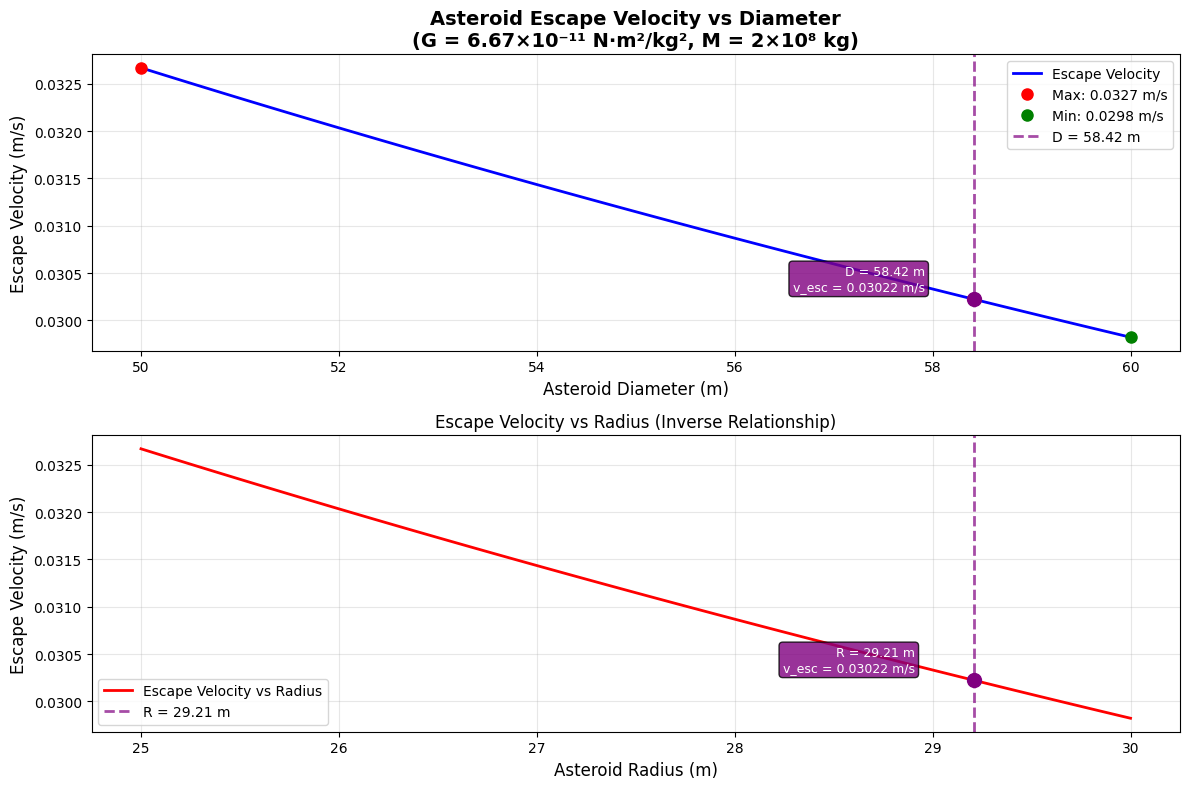

ASTEROIT KAÇIŞ HIZI HESAPLAMA SONUÇLARI
Gravitasyonel sabit (G): 6.67e-11 N⋅m²/kg²
Asteroit kütlesi (M_ast): 2.0e+08 kg
Çap aralığı: 50.0 - 60.0 m
------------------------------------------------------------
Minimum çap (60.0 m) için:
  • Yarıçap: 30.0 m
  • Kaçış hızı: 0.0298 m/s
Maksimum çap (50.0 m) için:
  • Yarıçap: 25.0 m
  • Kaçış hızı: 0.0327 m/s
Spesifik çap (58.42 m) için:
  • Yarıçap: 29.21 m
  • Kaçış hızı: 0.030222 m/s
------------------------------------------------------------
Kaçış hızı değişimi: 0.0028 m/s
Yüzde değişim: 9.54%

DETAYLI DEĞERLER
Çap (m)  | Yarıçap (m) | Kaçış Hızı (m/s)
----------------------------------------
  50.0   |     25.0    |    0.032668
  50.1   |     25.1    |    0.032635
  50.2   |     25.1    |    0.032602
  50.3   |     25.2    |    0.032569
  50.4   |     25.2    |    0.032537
   ...   |     ...     |      ...
  58.4   |     29.2    |    0.030222  ← SPESİFİK
   ...   |     ...     |      ...
  59.6   |     29.8    |    0.029923
  59.7   |

In [10]:
# Sabitler
G = 6.67e-11  # N⋅m²/kg² (Gravitasyonel sabit)
M_ast = 2e8   # kg (Asteroit kütlesi)

# Çap değerleri (50-60 m arası)
d_ast = np.linspace(50, 60, 100)  # 50'den 60'a 100 nokta

# Yarıçap hesaplama
r_ast = d_ast / 2  # r = d/2

# Kaçış hızı hesaplama
# v_esc = sqrt(2 * G * M_ast / r_ast)
v_esc = np.sqrt(2 * G * M_ast / r_ast)

# Spesifik çap için hesaplama
specific_diameter = 58.42  # m
specific_radius = specific_diameter / 2
specific_v_esc = np.sqrt(2 * G * M_ast / specific_radius)

print(f"Çap {specific_diameter} m için kaçış hızı: {specific_v_esc:.6f} m/s")

# Grafik oluşturma
plt.figure(figsize=(12, 8))

# Main plot
plt.subplot(2, 1, 1)
plt.plot(d_ast, v_esc, 'b-', linewidth=2, label='Escape Velocity')

# Mark important points
min_idx = 0  # Smallest diameter
max_idx = -1  # Largest diameter
plt.plot(d_ast[min_idx], v_esc[min_idx], 'ro', markersize=8, label=f'Max: {v_esc[min_idx]:.4f} m/s')
plt.plot(d_ast[max_idx], v_esc[max_idx], 'go', markersize=8, label=f'Min: {v_esc[max_idx]:.4f} m/s')

# Add marker for specific diameter (58.42 m)
plt.axvline(x=specific_diameter, color='purple', linestyle='--', linewidth=2, alpha=0.7, label=f'D = {specific_diameter} m')
plt.scatter([specific_diameter], [specific_v_esc], color='purple', s=100, zorder=5)
plt.text(specific_diameter - 0.5, specific_v_esc + 0.0001, 
         f'D = {specific_diameter} m\nv_esc = {specific_v_esc:.5f} m/s', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='purple', alpha=0.8), 
         fontsize=9, ha='right', color='white')

plt.xlabel('Asteroid Diameter (m)', fontsize=12)
plt.ylabel('Escape Velocity (m/s)', fontsize=12)
plt.title('Asteroid Escape Velocity vs Diameter\n(G = 6.67×10⁻¹¹ N⋅m²/kg², M = 2×10⁸ kg)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

# Bottom plot - Radius vs Escape Velocity
plt.subplot(2, 1, 2)
plt.plot(r_ast, v_esc, 'r-', linewidth=2, label='Escape Velocity vs Radius')

# Add marker for specific radius (29.21 m)
plt.axvline(x=specific_radius, color='purple', linestyle='--', linewidth=2, alpha=0.7, label=f'R = {specific_radius} m')
plt.scatter([specific_radius], [specific_v_esc], color='purple', s=100, zorder=5)
plt.text(specific_radius - 0.3, specific_v_esc + 0.0001, 
         f'R = {specific_radius} m\nv_esc = {specific_v_esc:.5f} m/s', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='purple', alpha=0.8), 
         fontsize=9, ha='right', color='white')

plt.xlabel('Asteroid Radius (m)', fontsize=12)
plt.ylabel('Escape Velocity (m/s)', fontsize=12)
plt.title('Escape Velocity vs Radius (Inverse Relationship)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Sonuçları yazdır
print("=" * 60)
print("ASTEROIT KAÇIŞ HIZI HESAPLAMA SONUÇLARI")
print("=" * 60)
print(f"Gravitasyonel sabit (G): {G:.2e} N⋅m²/kg²")
print(f"Asteroit kütlesi (M_ast): {M_ast:.1e} kg")
print(f"Çap aralığı: {d_ast[0]:.1f} - {d_ast[-1]:.1f} m")
print("-" * 60)
print(f"Minimum çap ({d_ast[-1]:.1f} m) için:")
print(f"  • Yarıçap: {r_ast[-1]:.1f} m")
print(f"  • Kaçış hızı: {v_esc[-1]:.4f} m/s")
print(f"Maksimum çap ({d_ast[0]:.1f} m) için:")
print(f"  • Yarıçap: {r_ast[0]:.1f} m") 
print(f"  • Kaçış hızı: {v_esc[0]:.4f} m/s")
print(f"Spesifik çap ({specific_diameter} m) için:")
print(f"  • Yarıçap: {specific_radius} m")
print(f"  • Kaçış hızı: {specific_v_esc:.6f} m/s")
print("-" * 60)
print(f"Kaçış hızı değişimi: {v_esc[0] - v_esc[-1]:.4f} m/s")
print(f"Yüzde değişim: {((v_esc[0] - v_esc[-1])/v_esc[-1] * 100):.2f}%")

# Detaylı tablo (ilk ve son 5 değer + spesifik değer)
print("\n" + "=" * 60)
print("DETAYLI DEĞERLER")
print("=" * 60)
print("Çap (m)  | Yarıçap (m) | Kaçış Hızı (m/s)")
print("-" * 40)

# İlk 5 değer
for i in range(5):
    print(f"{d_ast[i]:6.1f}   | {r_ast[i]:8.1f}    | {v_esc[i]:11.6f}")

print("   ...   |     ...     |      ...")

# Spesifik değer
print(f"{specific_diameter:6.1f}   | {specific_radius:8.1f}    | {specific_v_esc:11.6f}  ← SPESİFİK")

print("   ...   |     ...     |      ...")

# Son 5 değer
for i in range(-5, 0):
    print(f"{d_ast[i]:6.1f}   | {r_ast[i]:8.1f}    | {v_esc[i]:11.6f}")

# Matematik kontrolü
print("\n" + "=" * 60)
print("FORMÜL KONTROLÜ")
print("=" * 60)
print("Kullanılan formül: v_esc = √(2 × G × M_ast / r_ast)")
print(f"Spesifik hesaplama (çap = {specific_diameter} m):")
print(f"  • r_ast = {specific_radius} m")
print(f"  • v_esc = √(2 × {G:.2e} × {M_ast:.1e} / {specific_radius})")
print(f"  • v_esc = √({2 * G * M_ast / specific_radius:.6e})")
print(f"  • v_esc = {specific_v_esc:.6f} m/s")

# Dosyaya kaydet (isteğe bağlı)
# np.savetxt('asteroit_kacis_hizi.txt', 
#            np.column_stack((d_ast, r_ast, v_esc)), 
#            header='Çap(m) Yarıçap(m) KaçışHızı(m/s)', 
#            fmt='%.3f')
# print(f"\nVeriler 'asteroit_kacis_hizi.txt' dosyasına kaydedildi.")